# XGBM & LGBM

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.model_selection import train_test_split ,KFold ,cross_val_score
import xgboost as xg
from lightgbm import LGBMClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# Importing Train Dataset

In [29]:
train = pd.read_csv('Titanic_train.csv')
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


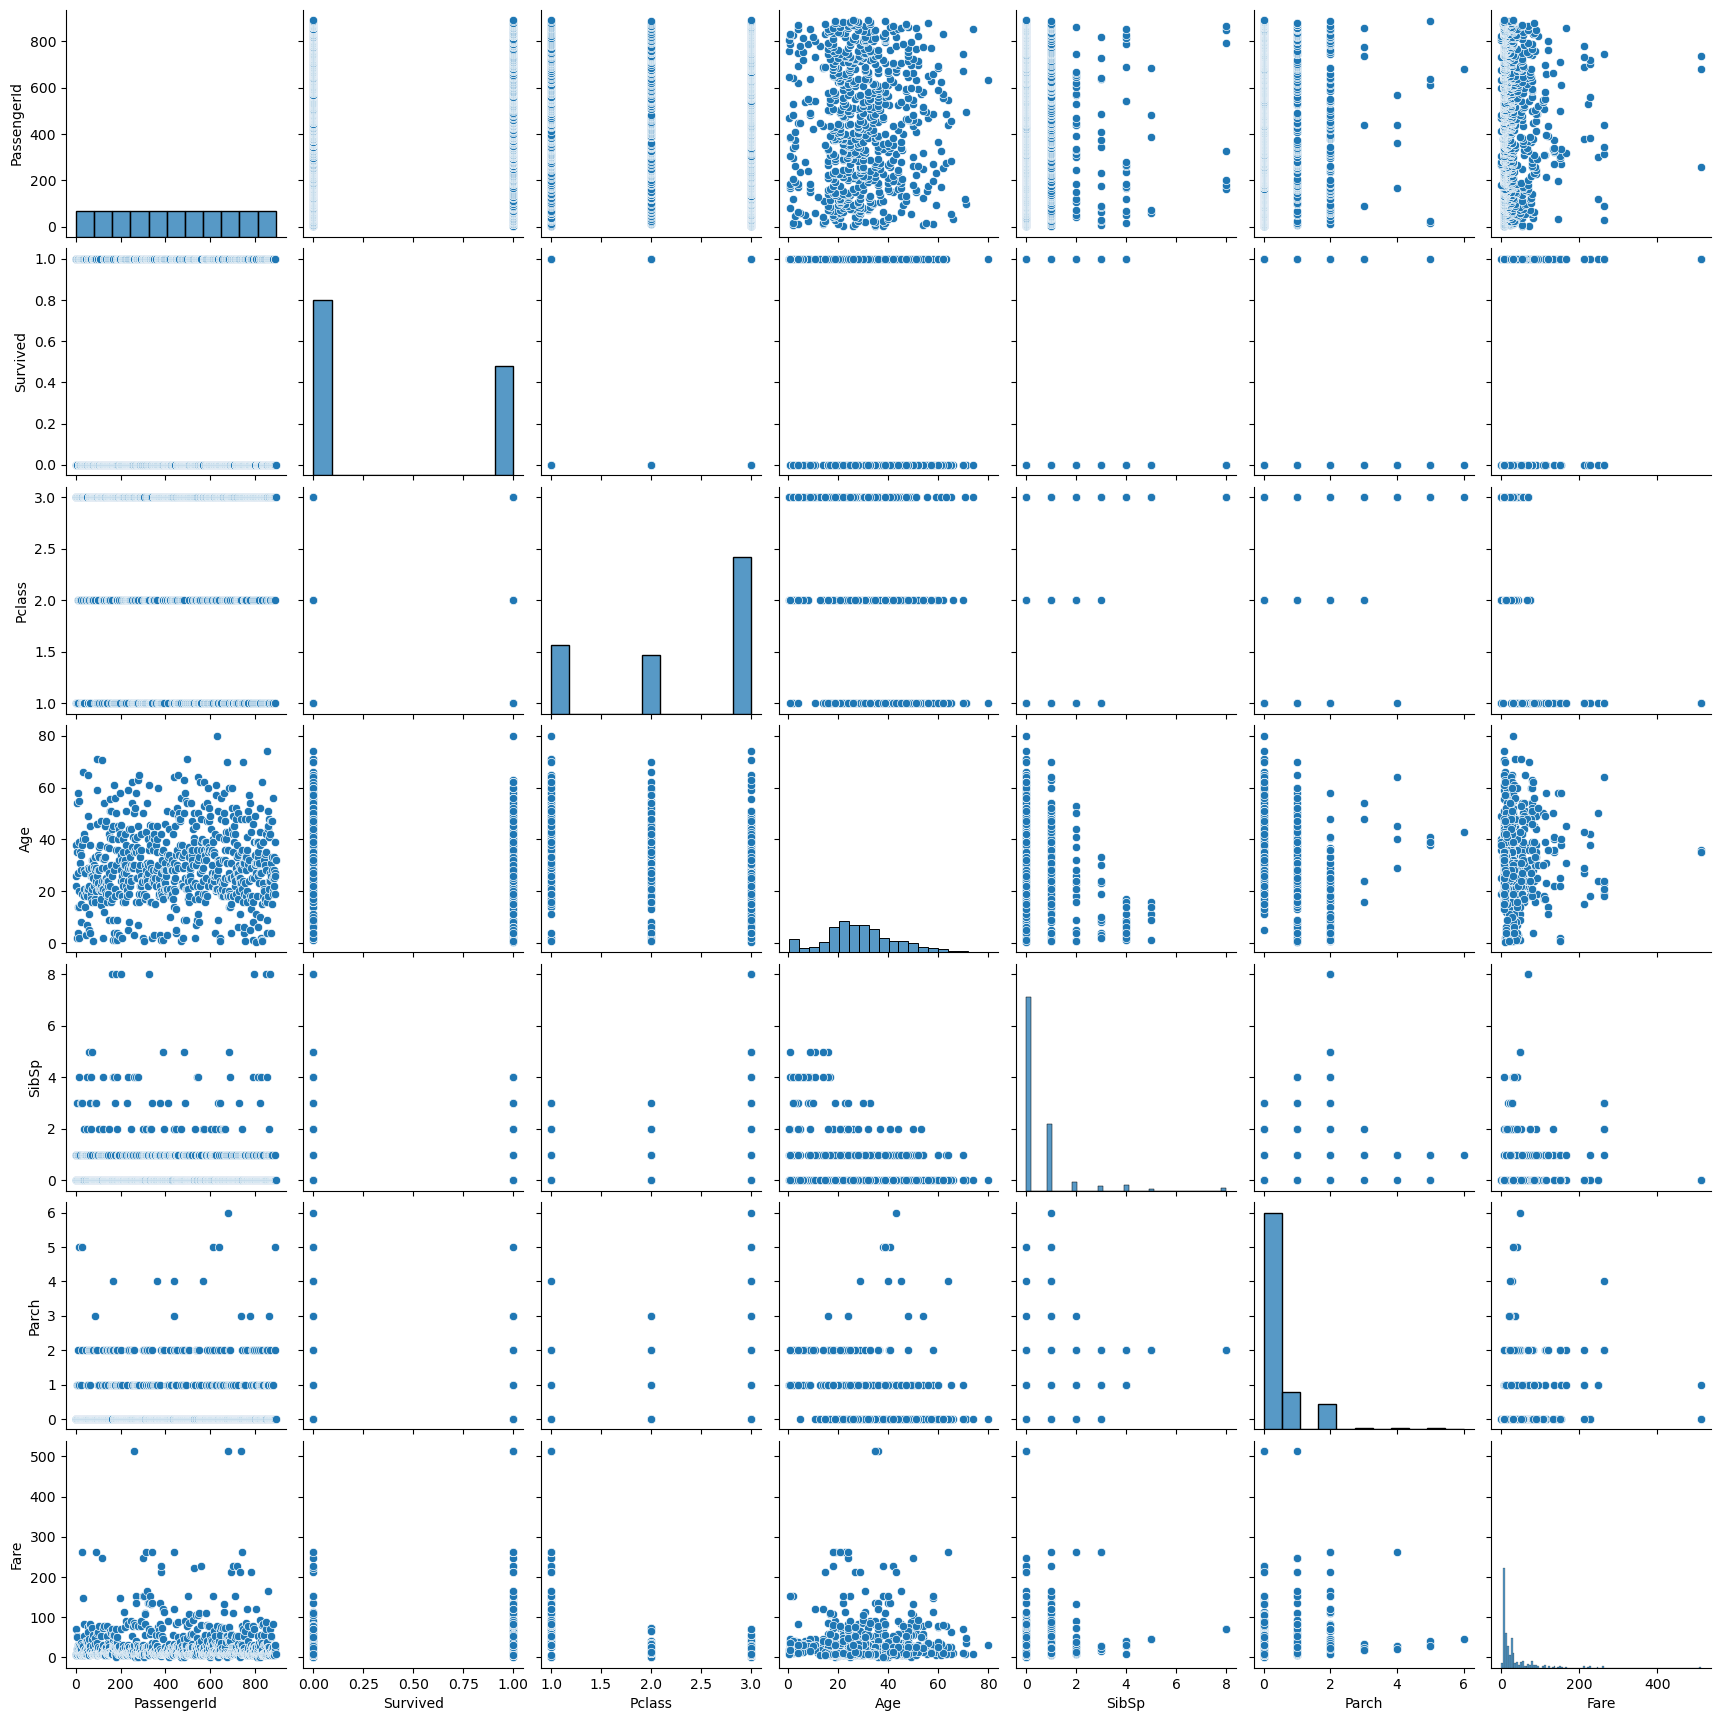

In [31]:
sns.pairplot(train)

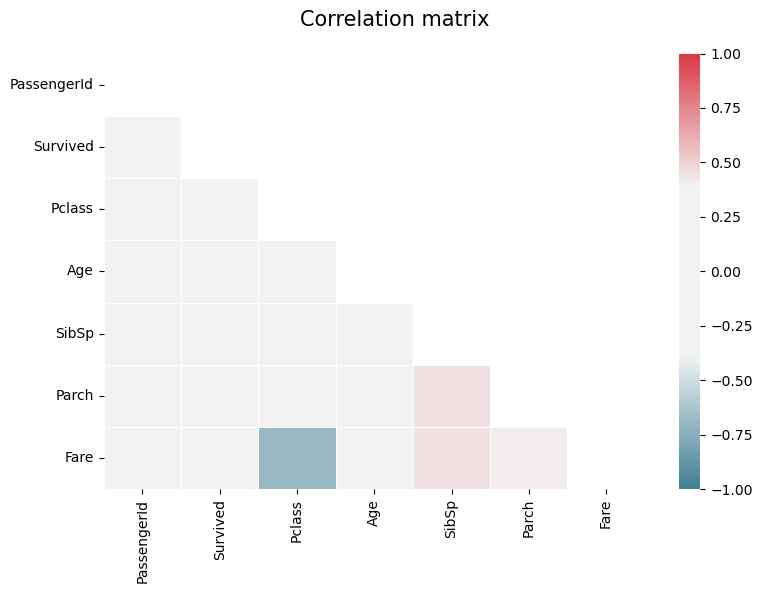

In [32]:
corr = train.corr(method='spearman')

# Generating a mask for the upper triangle
mask = np.zeros_like(corr,)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(8, 6))

cmap = sns.diverging_palette(220, 10, as_cmap=True, sep=100)

sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0, linewidths=.5)

fig.suptitle('Correlation matrix', fontsize=15)
fig.tight_layout()

In [33]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Filling Missing Values of Train Data

In [34]:
# continuous features --> fill the NAs with Mean
# categorical features --> fill the NAs with Mode

for clm in train.columns:
    if train[clm].dtype == 'int64' or train[clm].dtype == 'float64':
        train[clm].fillna(train[clm].mean(), inplace = True)
        
            
    if train[clm].dtype == 'object':
        train[clm].fillna(train[clm].mode()[0], inplace = True)
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [35]:
standard = StandardScaler()
for clm in train.columns:
    if train[clm].dtype == 'int64' or train[clm].dtype == 'float64':
        if clm not in ['Survived']:
            train[clm] = standard.fit_transform(np.array(train[clm]).reshape(-1,1))

train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,-1.730108,0,0.827377,"Braund, Mr. Owen Harris",male,-0.592481,0.432793,-0.473674,A/5 21171,-0.502445,B96 B98,S
1,-1.726220,1,-1.566107,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.638789,0.432793,-0.473674,PC 17599,0.786845,C85,C
2,-1.722332,1,0.827377,"Heikkinen, Miss. Laina",female,-0.284663,-0.474545,-0.473674,STON/O2. 3101282,-0.488854,B96 B98,S
3,-1.718444,1,-1.566107,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.407926,0.432793,-0.473674,113803,0.420730,C123,S
4,-1.714556,0,0.827377,"Allen, Mr. William Henry",male,0.407926,-0.474545,-0.473674,373450,-0.486337,B96 B98,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,1.714556,0,-0.369365,"Montvila, Rev. Juozas",male,-0.207709,-0.474545,-0.473674,211536,-0.386671,B96 B98,S
887,1.718444,1,-1.566107,"Graham, Miss. Margaret Edith",female,-0.823344,-0.474545,-0.473674,112053,-0.044381,B42,S
888,1.722332,0,0.827377,"Johnston, Miss. Catherine Helen ""Carrie""",female,0.000000,0.432793,2.008933,W./C. 6607,-0.176263,B96 B98,S
889,1.726220,1,-1.566107,"Behr, Mr. Karl Howell",male,-0.284663,-0.474545,-0.473674,111369,-0.044381,C148,C


In [36]:
le = LabelEncoder()

for clm in train.columns:
    if train[clm].dtype == 'object':
        train[clm] = le.fit_transform(np.array(train[clm]).reshape(-1,1))
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,-1.730108,0,0.827377,108,1,-0.592481,0.432793,-0.473674,523,-0.502445,47,2
1,-1.726220,1,-1.566107,190,0,0.638789,0.432793,-0.473674,596,0.786845,81,0
2,-1.722332,1,0.827377,353,0,-0.284663,-0.474545,-0.473674,669,-0.488854,47,2
3,-1.718444,1,-1.566107,272,0,0.407926,0.432793,-0.473674,49,0.420730,55,2
4,-1.714556,0,0.827377,15,1,0.407926,-0.474545,-0.473674,472,-0.486337,47,2
...,...,...,...,...,...,...,...,...,...,...,...,...
886,1.714556,0,-0.369365,548,1,-0.207709,-0.474545,-0.473674,101,-0.386671,47,2
887,1.718444,1,-1.566107,303,0,-0.823344,-0.474545,-0.473674,14,-0.044381,30,2
888,1.722332,0,0.827377,413,0,0.000000,0.432793,2.008933,675,-0.176263,47,2
889,1.726220,1,-1.566107,81,1,-0.284663,-0.474545,-0.473674,8,-0.044381,60,0


# Importing The Test Dataset

In [37]:
test = pd.read_csv('Titanic_test.csv')
test

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,1,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,1,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,0,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,1,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [38]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        88 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


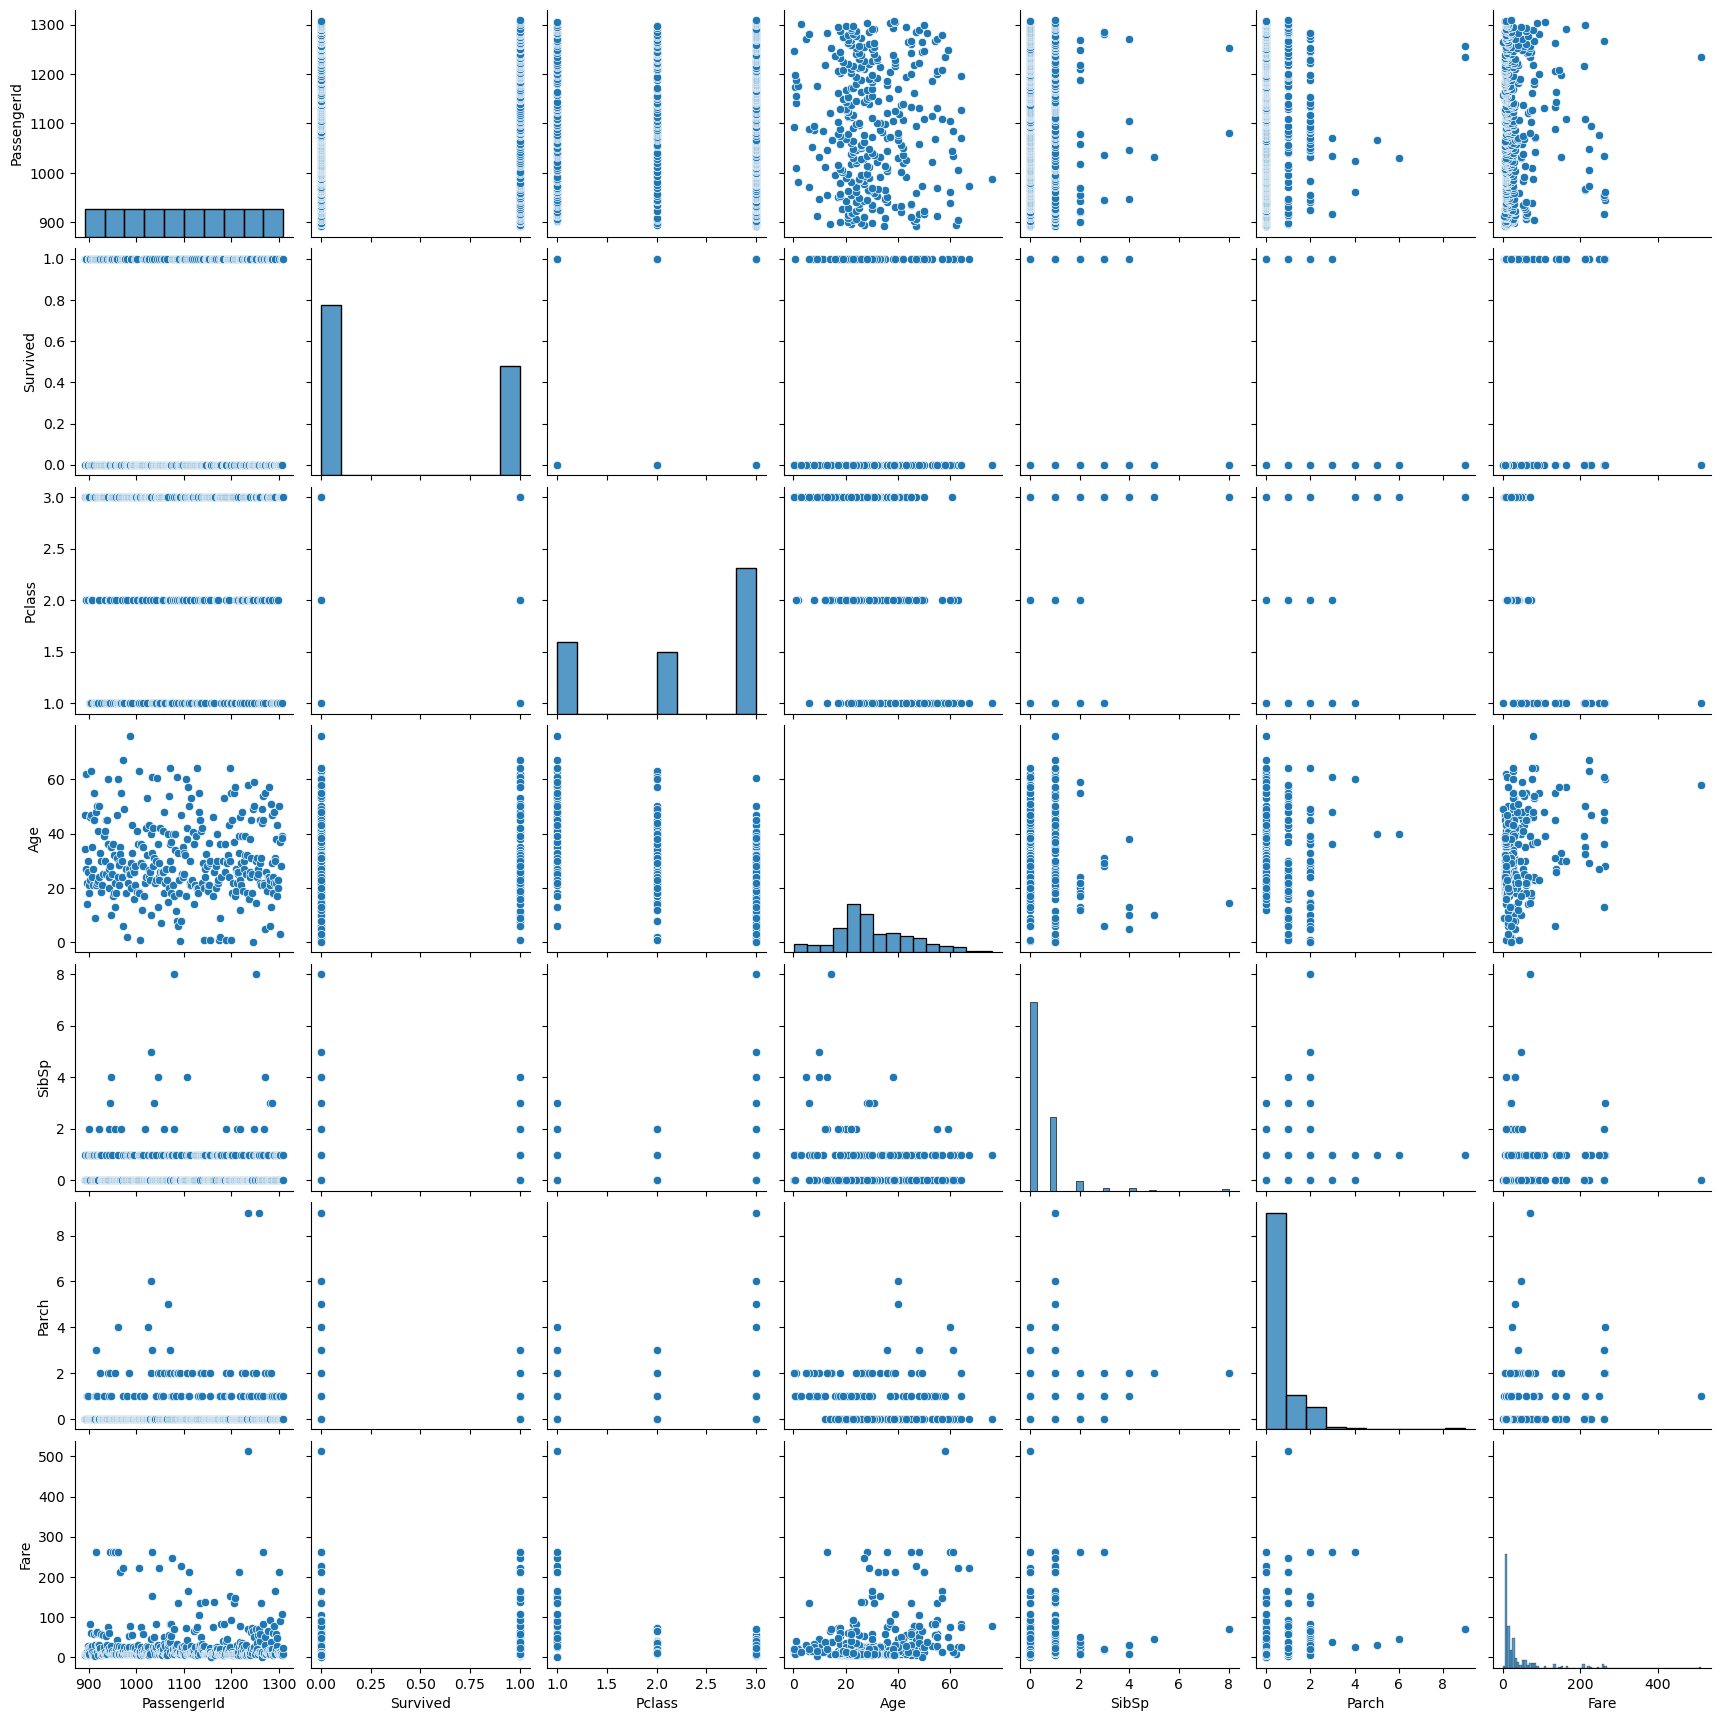

In [39]:
sns.pairplot(test)

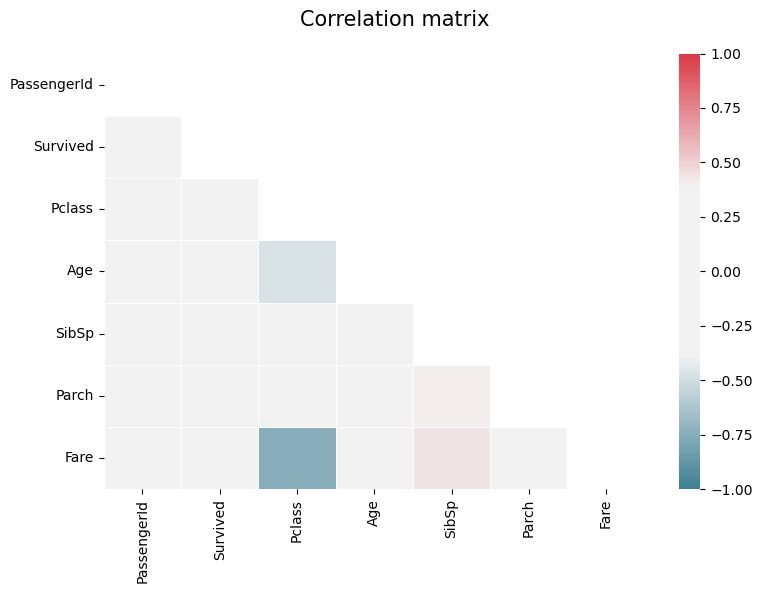

In [40]:
corr = test.corr(method='spearman')

# Generating a mask for the upper triangle
mask = np.zeros_like(corr,)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(8, 6))

cmap = sns.diverging_palette(220, 10, as_cmap=True, sep=100)

sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0, linewidths=.5)

fig.suptitle('Correlation matrix', fontsize=15)
fig.tight_layout()

In [41]:
test.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          330
Embarked         0
dtype: int64

# Filling Missing Values of Test Data

In [42]:
# continuous features --> fill the NAs with Mean
# categorical features --> fill the NAs with Mode

for clm in test.columns:
    if test[clm].dtype == 'int64' or test[clm].dtype == 'float64':
        test[clm].fillna(test[clm].mean(), inplace = True)
        
            
    if test[clm].dtype == 'object':
        test[clm].fillna(test[clm].mode()[0], inplace = True)
test.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [43]:
standard = StandardScaler()
for clm in test.columns:
    if test[clm].dtype == 'int64' or test[clm].dtype == 'float64':
        if clm not in ['Survived']:
            test[clm] = standard.fit_transform(np.array(test[clm]).reshape(-1,1))

test

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,-1.727912,0,0.873482,"Kelly, Mr. James",male,0.334993,-0.499470,-0.400248,330911,-0.498407,A34,Q
1,-1.719625,1,0.873482,"Wilkes, Mrs. James (Ellen Needs)",female,1.325530,0.616992,-0.400248,363272,-0.513274,A34,S
2,-1.711337,1,-0.315819,"Myles, Mr. Thomas Francis",male,2.514175,-0.499470,-0.400248,240276,-0.465088,A34,Q
3,-1.703050,1,0.873482,"Wirz, Mr. Albert",male,-0.259330,-0.499470,-0.400248,315154,-0.483466,A34,S
4,-1.694763,0,0.873482,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,-0.655545,0.616992,0.619896,3101298,-0.418471,A34,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1.694763,0,0.873482,"Spector, Mr. Woolf",male,0.000000,-0.499470,-0.400248,A.5. 3236,-0.494448,A34,S
414,1.703050,1,-1.505120,"Oliva y Ocana, Dona. Fermina",female,0.691586,-0.499470,-0.400248,PC 17758,1.313753,C105,C
415,1.711337,0,0.873482,"Saether, Mr. Simon Sivertsen",male,0.651965,-0.499470,-0.400248,SOTON/O.Q. 3101262,-0.508792,A34,S
416,1.719625,1,0.873482,"Ware, Mr. Frederick",male,0.000000,-0.499470,-0.400248,359309,-0.494448,A34,S


In [44]:
le = LabelEncoder()

for clm in test.columns:
    if test[clm].dtype == 'object':
        test[clm] = le.fit_transform(np.array(test[clm]).reshape(-1,1))
test

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,-1.727912,0,0.873482,206,1,0.334993,-0.499470,-0.400248,152,-0.498407,4,1
1,-1.719625,1,0.873482,403,0,1.325530,0.616992,-0.400248,221,-0.513274,4,2
2,-1.711337,1,-0.315819,269,1,2.514175,-0.499470,-0.400248,73,-0.465088,4,1
3,-1.703050,1,0.873482,408,1,-0.259330,-0.499470,-0.400248,147,-0.483466,4,2
4,-1.694763,0,0.873482,178,0,-0.655545,0.616992,0.619896,138,-0.418471,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1.694763,0,0.873482,353,1,0.000000,-0.499470,-0.400248,267,-0.494448,4,2
414,1.703050,1,-1.505120,283,0,0.691586,-0.499470,-0.400248,324,1.313753,22,0
415,1.711337,0,0.873482,332,1,0.651965,-0.499470,-0.400248,346,-0.508792,4,2
416,1.719625,1,0.873482,384,1,0.000000,-0.499470,-0.400248,220,-0.494448,4,2


# Splitting the test train data

In [45]:
X_train=train.drop(columns='Survived')
y_train=train.iloc[:,1]
X_test=test.drop(columns='Survived')
y_test=test.iloc[:,1]
X_train

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,-1.730108,0.827377,108,1,-0.592481,0.432793,-0.473674,523,-0.502445,47,2
1,-1.726220,-1.566107,190,0,0.638789,0.432793,-0.473674,596,0.786845,81,0
2,-1.722332,0.827377,353,0,-0.284663,-0.474545,-0.473674,669,-0.488854,47,2
3,-1.718444,-1.566107,272,0,0.407926,0.432793,-0.473674,49,0.420730,55,2
4,-1.714556,0.827377,15,1,0.407926,-0.474545,-0.473674,472,-0.486337,47,2
...,...,...,...,...,...,...,...,...,...,...,...
886,1.714556,-0.369365,548,1,-0.207709,-0.474545,-0.473674,101,-0.386671,47,2
887,1.718444,-1.566107,303,0,-0.823344,-0.474545,-0.473674,14,-0.044381,30,2
888,1.722332,0.827377,413,0,0.000000,0.432793,2.008933,675,-0.176263,47,2
889,1.726220,-1.566107,81,1,-0.284663,-0.474545,-0.473674,8,-0.044381,60,0


# Building The Model 

In [46]:
boost = xg.XGBClassifier()
boost.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

# Predicting on test data

In [47]:
y_pred = boost.predict(X_test)
metrics.accuracy_score(y_pred,y_test)

0.5023923444976076

In [48]:
confusion_matrix(y_test,y_pred)

array([[149, 106],
       [102,  61]], dtype=int64)

In [49]:
print(boost.feature_importances_)

[0.02540246 0.18359144 0.03092946 0.45138207 0.0338855  0.08442693
 0.03559126 0.03878054 0.03458661 0.0431079  0.03831578]


# Cross Validation to improve accuracy

In [50]:
kfold = KFold(n_splits= 10)
results = cross_val_score(boost, X_train, y_train, cv= kfold)
print(results.mean())

0.8339076154806492


Text(277.72222222222223, 0.5, 'predicted label')

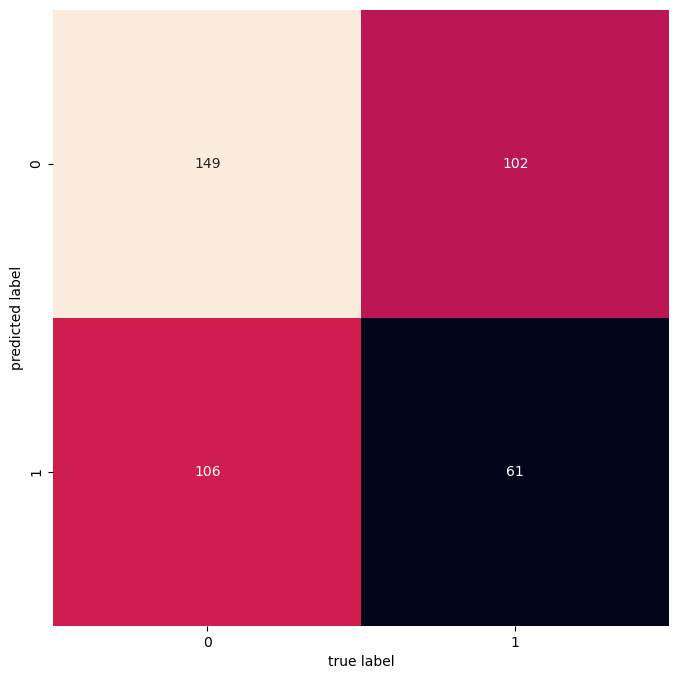

In [51]:
# Ploting the confusion matrix
mat = confusion_matrix(y_test, y_pred)
plt.subplots(figsize=(12,8))
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label')

# Trying With LGBM

In [77]:
lg = LGBMClassifier()
lg.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1052
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288


LGBMClassifier()

In [78]:
lg.score

<bound method ClassifierMixin.score of LGBMClassifier()>

In [101]:
y_pred_lg = lg.predict(X_test)
metrics.accuracy_score(y_pred_lg,y_test)

0.5167464114832536

In [102]:
confusion_matrix(y_test,y_pred_lg)

array([[156,  99],
       [103,  60]], dtype=int64)

In [85]:
print(lg.feature_importances_)

[565  68 602  85 462  47  23 532 468 101  47]


In [97]:
kfold = KFold(n_splits= 10)
results = cross_val_score(lg, X_train, y_train, cv= kfold)
print(results.mean())  # result = 0.8283270911360798

[LightGBM] [Info] Number of positive: 303, number of negative: 498
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000189 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1035
[LightGBM] [Info] Number of data points in the train set: 801, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.378277 -> initscore=-0.496867
[LightGBM] [Info] Start training from score -0.496867
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

Text(277.72222222222223, 0.5, 'predicted label')

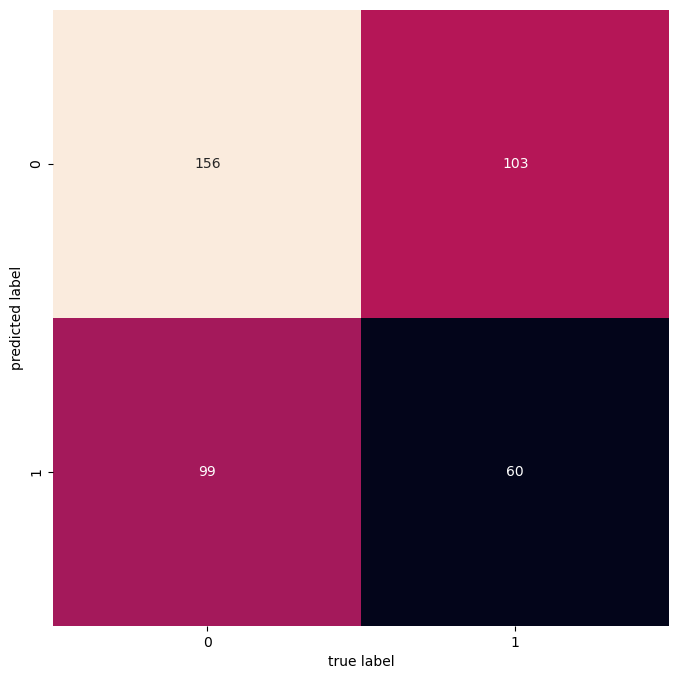

In [98]:
# Ploting the confusion matrix
mat = confusion_matrix(y_test, y_pred)
plt.subplots(figsize=(12,8))
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label')

In [103]:
print(classification_report(y_test, y_pred_lg))

              precision    recall  f1-score   support

           0       0.60      0.61      0.61       255
           1       0.38      0.37      0.37       163

    accuracy                           0.52       418
   macro avg       0.49      0.49      0.49       418
weighted avg       0.51      0.52      0.52       418

